# Chapter 6 — Building Your First Deep Neural Network

**Grokking Deep Learning — Andrew W. Trask**


> **Catatan visual:** Pada Chapter 6 ini, Angka yang berasal dari eksperimen buku tetap dihitung dari kode/data buku.

## Learning Objectives

Chapter ini mulai menggabungkan konsep sebelumnya menjadi **deep neural network**.

Fokus:
- Streetlight problem
- Data matrix
- Forward propagation
- Learning an entire dataset
- Stochastic, full, dan batch gradient descent
- Neural networks learn correlation
- Overfitting dan conflicting pressure
- Indirect correlation
- Nonlinearity dengan **ReLU**
- Backpropagation
- One iteration of backpropagation
- Deep neural network end-to-end

## Chapter Roadmap

**Data → Forward Propagation → Error → Backpropagation → Weight Update**

Pada Chapter 5 kita sudah memiliki multiple inputs dan multiple outputs. Chapter 6 menambahkan **hidden layer**, sehingga error dari output dapat diteruskan kembali ke layer sebelumnya.

## 1. The Streetlight Problem

Buku menggunakan masalah sederhana: dari pola tiga lampu jalan, network harus memprediksi apakah orang **WALK** atau **STOP**.

Pola yang digunakan dalam bagian persiapan data:

| Light 1 | Light 2 | Light 3 | Target |
|---:|---:|---:|---|
| 1 | 0 | 1 | STOP |
| 0 | 1 | 1 | WALK |
| 0 | 0 | 1 | WALK |
| 1 | 1 | 1 | WALK |
| 0 | 1 | 1 | STOP |
| 1 | 0 | 1 | STOP |

Buku menunjukkan bahwa **middle light** memiliki korelasi sempurna dengan keputusan walk/stop pada contoh pengamatan tersebut.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

streetlights_6 = np.array([
    [1, 0, 1],
    [0, 1, 1],
    [0, 0, 1],
    [1, 1, 1],
    [0, 1, 1],
    [1, 0, 1]
])

targets_6 = np.array([0, 1, 1, 1, 0, 0])

print("Streetlight matrix:")
print(streetlights_6)
print("Targets:", targets_6)

Streetlight matrix:
[[1 0 1]
 [0 1 1]
 [0 0 1]
 [1 1 1]
 [0 1 1]
 [1 0 1]]
Targets: [0 1 1 1 0 0]


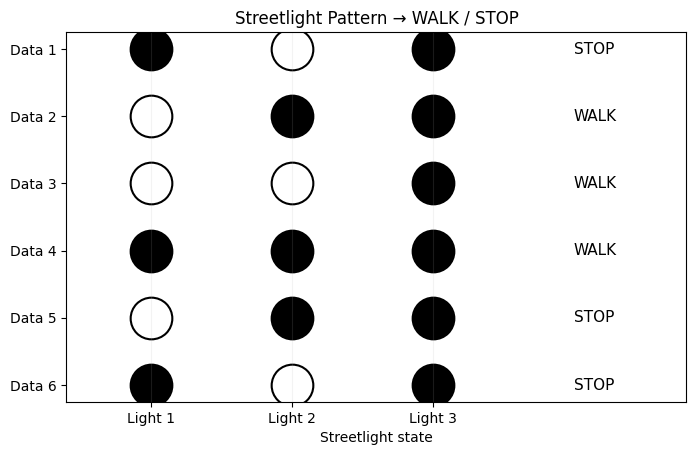

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.8))

for row_idx, row in enumerate(streetlights_6):
    for col_idx, value in enumerate(row):
        ax.scatter(col_idx, row_idx, s=900, facecolors="white" if value == 0 else "black",
                   edgecolors="black", linewidths=1.5)

for row_idx, target in enumerate(targets_6):
    label = "WALK" if target == 1 else "STOP"
    ax.text(3.0, row_idx, label, va="center", fontsize=11)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Light 1", "Light 2", "Light 3"])
ax.set_yticks(range(6))
ax.set_yticklabels([f"Data {i+1}" for i in range(6)])
ax.invert_yaxis()
ax.set_xlim(-0.6, 3.8)
ax.set_title("Streetlight Pattern → WALK / STOP")
ax.set_xlabel("Streetlight state")
ax.grid(axis="x", alpha=0.15)
plt.show()

### Apa yang perlu dilihat?

Tidak perlu membaca matrix angka satu per satu. Pada visual di atas:

- lingkaran **hitam** = lampu `1` / ON
- lingkaran **putih** = lampu `0` / OFF
- label kanan = target `WALK` atau `STOP`

Visual ini mempertahankan **data yang sama dengan tabel**, hanya mengubah cara membacanya agar pola lebih mudah terlihat.

## 2. Matrices and the Matrix Relationship

Buku kemudian menerjemahkan streetlight menjadi angka.

Setiap **row** = satu pengamatan streetlight.

Setiap **column** = satu lampu.

Dengan demikian, matrix data dapat langsung menjadi input neural network.

Shape of the six-example dataset: (6, 3)
Rows = observations: 6
Columns = lights: 3


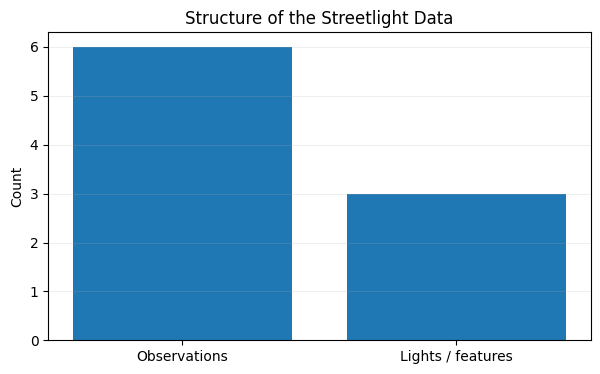

In [ ]:
print("Shape of the six-example dataset:", streetlights_6.shape)
print("Rows = observations:", streetlights_6.shape[0])
print("Columns = lights:", streetlights_6.shape[1])

plt.figure(figsize=(7, 4))
plt.bar(["Observations", "Lights / features"],
        [streetlights_6.shape[0], streetlights_6.shape[1]])
plt.ylabel("Count")
plt.title("Structure of the Streetlight Data")
plt.grid(axis="y", alpha=0.2)
plt.show()

## 3. The Dataset Used in the Runnable Network

Pada bagian **Building your first deep neural network**, buku menggunakan dataset runnable yang lebih kecil:

```text
[[1, 0, 1],
 [0, 1, 1],
 [0, 0, 1],
 [1, 1, 1]]
```

dengan target:

```text
[[1],
 [1],
 [0],
 [0]]
```

Notebook mempertahankan dataset runnable tersebut secara persis untuk reproduksi kode training.

In [ ]:
streetlights = np.array([
    [1, 0, 1],
    [0, 1, 1],
    [0, 0, 1],
    [1, 1, 1]
])

walk_vs_stop = np.array([[1, 1, 0, 0]]).T

print("Input:")
print(streetlights)
print("\nTarget:")
print(walk_vs_stop)

Input:
[[1 0 1]
 [0 1 1]
 [0 0 1]
 [1 1 1]]

Target:
[[1]
 [1]
 [0]
 [0]]


## 4. Forward Propagation: Three Layers

Struktur network pada Chapter 6:

**layer_0 → layer_1 → layer_2**

- `layer_0` = input streetlight
- `layer_1` = hidden / intermediate layer
- `layer_2` = final prediction
- `weights_0_1` = hubungan input → hidden
- `weights_1_2` = hubungan hidden → output

Buku menggunakan `hidden_size = 4` pada runnable network utama.

In [ ]:
np.random.seed(1)

def relu(x):
    return (x > 0) * x

alpha = 0.2
hidden_size = 4

weights_0_1 = 2*np.random.random((3, hidden_size)) - 1
weights_1_2 = 2*np.random.random((hidden_size, 1)) - 1

layer_0 = streetlights[0]
layer_1 = relu(np.dot(layer_0, weights_0_1))
layer_2 = np.dot(layer_1, weights_1_2)

print("layer_0:", layer_0)
print("layer_1:", layer_1)
print("layer_2:", layer_2)

layer_0: [1 0 1]
layer_1: [-0.          0.51828245 -0.         -0.        ]
layer_2: [0.39194327]


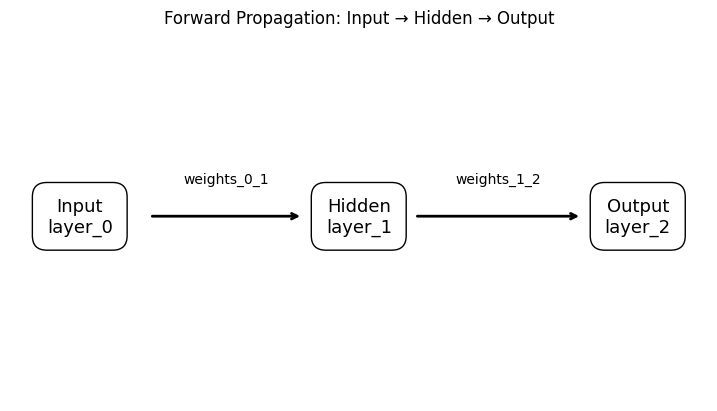

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.8))

nodes = {
    "Input\nlayer_0": (0.1, 0.5),
    "Hidden\nlayer_1": (0.5, 0.5),
    "Output\nlayer_2": (0.9, 0.5)
}

for name, (x, y) in nodes.items():
    ax.text(x, y, name, ha="center", va="center", fontsize=13,
            bbox=dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black"))

ax.annotate("", xy=(0.42, 0.5), xytext=(0.2, 0.5),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(0.82, 0.5), xytext=(0.58, 0.5),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.text(0.31, 0.59, "weights_0_1", ha="center")
ax.text(0.70, 0.59, "weights_1_2", ha="center")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Forward Propagation: Input → Hidden → Output")
plt.show()

## 5. ReLU: Mengapa Hidden Layer Membutuhkan Nonlinearity?

Buku memperkenalkan **ReLU**:

\[
relu(x)=
egin{cases}
x, & x>0\
0, & x\leq0
\end{cases}
\]

Cara membaca fungsi ini sederhana: **nilai negatif dimatikan menjadi 0, sedangkan nilai positif diteruskan**.

Ini memungkinkan hidden layer memiliki *conditional correlation* yang tidak dapat diperoleh dari network linear sederhana.

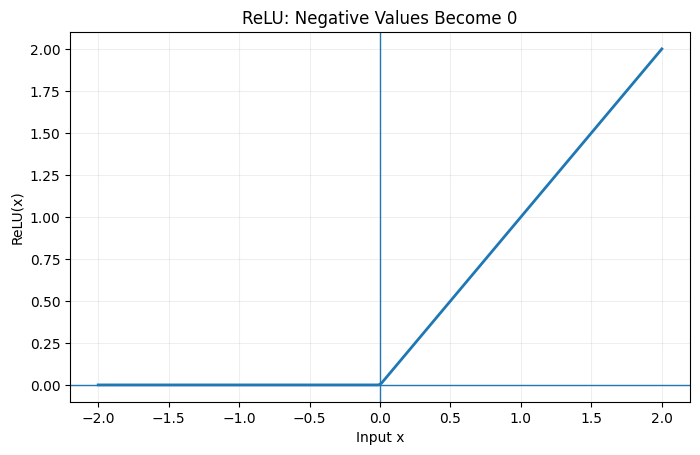

In [ ]:
x = np.linspace(-2, 2, 200)
y = relu(x)

plt.figure(figsize=(8, 4.8))
plt.plot(x, y, linewidth=2)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Input x")
plt.ylabel("ReLU(x)")
plt.title("ReLU: Negative Values Become 0")
plt.grid(alpha=0.2)
plt.show()

### Contoh langsung

Misalnya hidden layer menghasilkan nilai:

`[-1.0, 0.5, 1.0, -0.2]`

setelah ReLU menjadi:

`[0.0, 0.5, 1.0, 0.0]`

Jadi node yang menghasilkan nilai negatif tidak meneruskan signal ke layer berikutnya.

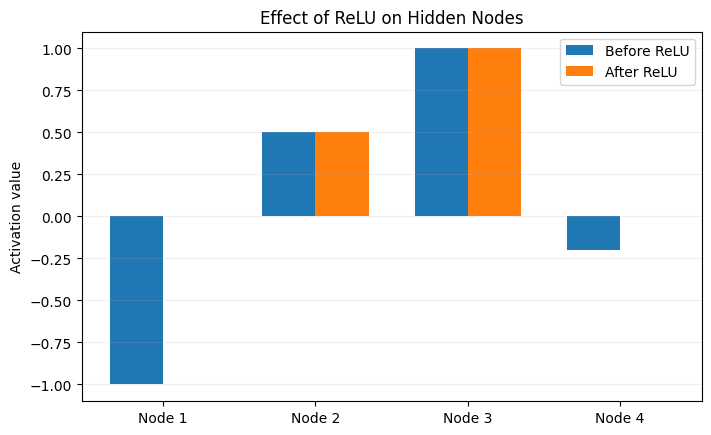

In [ ]:
before_relu = np.array([-1.0, 0.5, 1.0, -0.2])
after_relu = relu(before_relu)

plt.figure(figsize=(8, 4.8))
x_pos = np.arange(4)
width = 0.35
plt.bar(x_pos - width/2, before_relu, width, label="Before ReLU")
plt.bar(x_pos + width/2, after_relu, width, label="After ReLU")
plt.xticks(x_pos, ["Node 1", "Node 2", "Node 3", "Node 4"])
plt.ylabel("Activation value")
plt.title("Effect of ReLU on Hidden Nodes")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()

## 6. Learning the Whole Dataset

Buku menunjukkan bahwa training dilakukan dengan melihat training examples satu per satu.

Untuk setiap example:

**Predict → Compare → Calculate delta → Update weights**

Kemudian proses tersebut diulang berkali-kali sampai error seluruh dataset turun.

In [ ]:
# Reproduksi training single-layer dari bagian dataset learning
weights_single = np.array([0.0, 0.0, 0.0], dtype=float)
alpha_single = 0.2
error_history_single = []

for iteration in range(60):
    error_for_all_lights = 0

    for i in range(len(streetlights)):
        input_row = streetlights[i]
        goal_prediction = walk_vs_stop[i][0]
        prediction = np.dot(input_row, weights_single)

        error = (goal_prediction - prediction) ** 2
        error_for_all_lights += error

        delta = prediction - goal_prediction
        weights_single = weights_single - (alpha_single * (input_row * delta))

    error_history_single.append(error_for_all_lights)

print("Final weights:", weights_single)
print("Final dataset error:", error_history_single[-1])

Final weights: [ 1.95195626e-05 -1.24984562e-01  3.74974287e-01]
Final dataset error: 1.5625180763832247


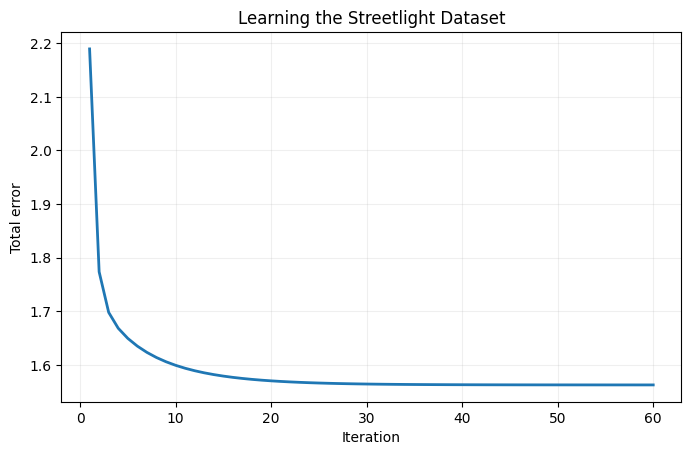

In [ ]:
plt.figure(figsize=(8, 4.8))
plt.plot(range(1, 61), error_history_single, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Total error")
plt.title("Learning the Streetlight Dataset")
plt.grid(alpha=0.2)
plt.show()

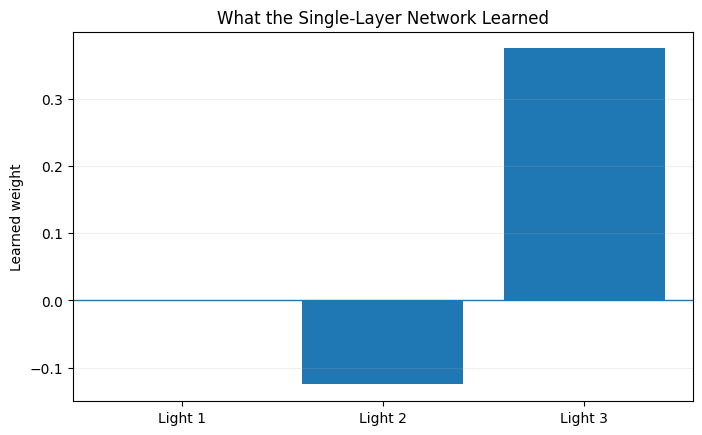

Learned weights: [ 1.95195626e-05 -1.24984562e-01  3.74974287e-01]


In [ ]:
plt.figure(figsize=(8, 4.8))
plt.bar(["Light 1", "Light 2", "Light 3"], weights_single)
plt.axhline(0, linewidth=1)
plt.ylabel("Learned weight")
plt.title("What the Single-Layer Network Learned")
plt.grid(axis="y", alpha=0.2)
plt.show()

print("Learned weights:", weights_single)

### Interpretasi

Buku menjelaskan bahwa network mengidentifikasi **middle light** sebagai input yang paling berkorelasi dengan output.

Karena itu, bentuk yang lebih mudah dipahami daripada heatmap adalah **bar chart weight**:

- weight mendekati 0 → kontribusi/correlation kecil
- weight yang lebih besar → signal lebih kuat dalam prediction

Visual di atas dihitung langsung dari training dataset, bukan dibuat sebagai angka ilustrasi.

## 7. Stochastic, Full, and Batch Gradient Descent

Buku membedakan tiga cara melakukan update:

| Method | Kapan weight di-update? |
|---|---|
| **Stochastic gradient descent** | Setelah setiap satu example |
| **Full gradient descent** | Setelah seluruh dataset |
| **Batch gradient descent** | Setelah sejumlah example tertentu |

Contoh training streetlight pada bagian ini menggunakan pendekatan **stochastic gradient descent**.

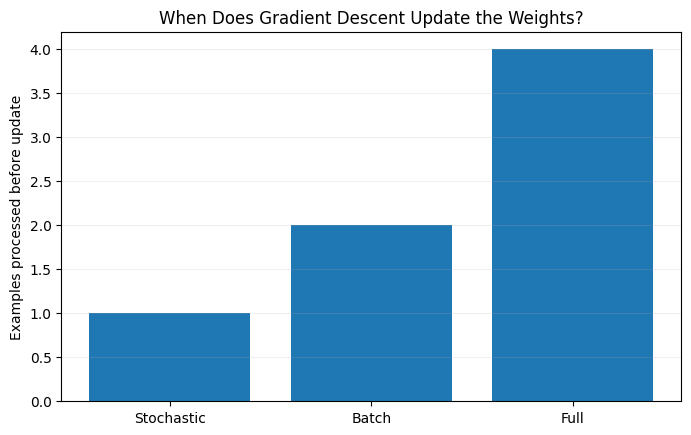

In [ ]:
methods = ["Stochastic", "Batch", "Full"]
examples_before_update = [1, 2, 4]

plt.figure(figsize=(8, 4.8))
plt.bar(methods, examples_before_update)
plt.ylabel("Examples processed before update")
plt.title("When Does Gradient Descent Update the Weights?")
plt.grid(axis="y", alpha=0.2)
plt.show()

**Catatan:** angka `2` untuk Batch pada visual adalah ilustrasi pilihan batch size, bukan angka wajib dari buku. Buku menjelaskan bahwa batch size dipilih oleh pengguna dan umumnya berada pada rentang tertentu. Karena itu visual ini hanya menunjukkan **perbedaan mekanisme**, bukan hasil eksperimen buku.

## 8. Neural Networks Learn Correlation

Setelah training, buku menginterpretasikan weight sebagai indikator correlation.

Pada dataset streetlight, middle light memiliki hubungan yang paling konsisten terhadap target. Karena itu network meningkatkan weight yang berkaitan dengan middle light sementara weight yang tidak informatif bergerak mendekati 0.

## 9. Upward and Downward Pressure

Setiap training example dapat memberi:
- **upward pressure** → weight didorong naik
- **downward pressure** → weight didorong turun

Jika signal dari sebuah input konsisten terhadap target, pressure akan terakumulasi ke satu arah. Jika tidak ada correlation yang jelas, pressure dapat saling meniadakan.

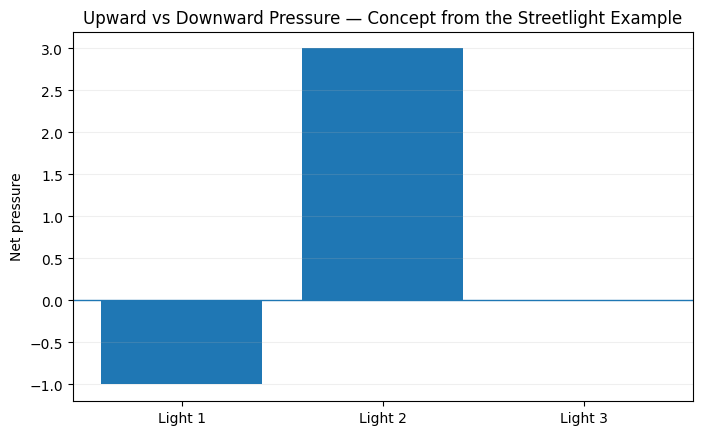

In [ ]:
pressure_example = np.array([
    [-1,  0, -1],
    [ 0,  1,  1],
    [ 0,  0, -1],
    [ 1,  1,  1],
    [ 0,  1,  1],
    [-1,  0, -1]
])

net_pressure = pressure_example.sum(axis=0)

plt.figure(figsize=(8, 4.8))
plt.bar(["Light 1", "Light 2", "Light 3"], net_pressure)
plt.axhline(0, linewidth=1)
plt.ylabel("Net pressure")
plt.title("Upward vs Downward Pressure — Concept from the Streetlight Example")
plt.grid(axis="y", alpha=0.2)
plt.show()

**Catatan akurasi:** tabel pressure pada buku menggunakan simbol `+`, `-`, dan `0` untuk menjelaskan konsep. Visual di atas menerjemahkan simbol tersebut menjadi `+1`, `-1`, dan `0` hanya agar dapat dihitung sebagai net pressure. Ini adalah visualisasi konsep, bukan runtime output dari training network.

## 10. Edge Case: Overfitting

Buku menjelaskan bahwa network yang terlalu fleksibel dapat menemukan konfigurasi weight yang cocok untuk sebagian training examples tetapi gagal pada pola yang lebih umum.

Intinya:

**Memorization ≠ Generalization**

Jika network hanya belajar contoh tertentu, ia belum tentu belajar correlation yang sebenarnya.

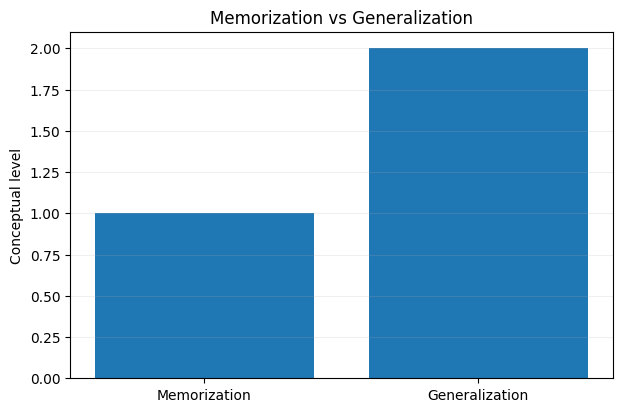

In [ ]:
categories = ["Memorization", "Generalization"]
characteristics = [1, 2]

plt.figure(figsize=(7, 4.5))
plt.bar(categories, characteristics)
plt.ylabel("Conceptual level")
plt.title("Memorization vs Generalization")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.show()

Visual di atas hanya membantu membedakan dua konsep; **tinggi batang tidak memiliki arti numerik**. Buku tidak memberikan skor numerik untuk memorization vs generalization.

## 11. Learning Indirect Correlation

Buku kemudian memberikan dataset yang tidak memiliki correlation langsung antara input dan output.

Solusinya adalah membuat **intermediate dataset**:

**Input → Hidden / Intermediate representation → Output**

Inilah ide dasar mengapa deep neural network menggunakan layer tambahan.

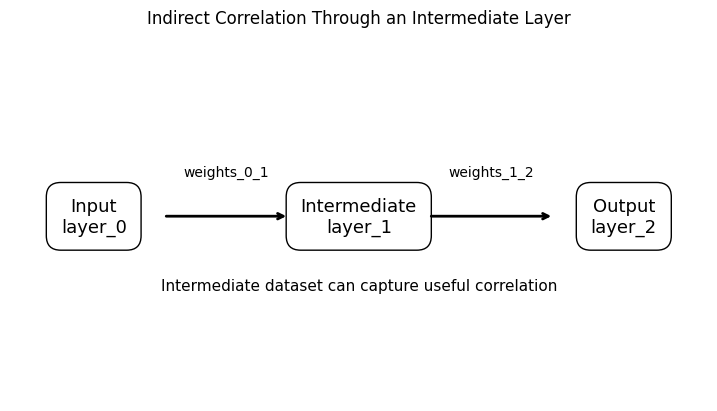

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.8))

labels = [
    ("Input\nlayer_0", 0.12),
    ("Intermediate\nlayer_1", 0.50),
    ("Output\nlayer_2", 0.88)
]

for label, x in labels:
    ax.text(x, 0.5, label, ha="center", va="center", fontsize=13,
            bbox=dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black"))

ax.annotate("", xy=(0.40, 0.5), xytext=(0.22, 0.5),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(0.78, 0.5), xytext=(0.60, 0.5),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.text(0.31, 0.61, "weights_0_1", ha="center")
ax.text(0.69, 0.61, "weights_1_2", ha="center")
ax.text(0.50, 0.30, "Intermediate dataset can capture useful correlation",
        ha="center", fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Indirect Correlation Through an Intermediate Layer")
plt.show()

## 12. Why ReLU Matters

Tanpa nonlinearity, hidden layer hanya meneruskan kombinasi linear dari input.

Dengan ReLU, hidden node dapat **aktif pada kondisi tertentu dan mati pada kondisi lain**.

Buku menyebut kemampuan ini sebagai **sometimes correlation / conditional correlation**, yang memberi three-layer network kemampuan lebih besar daripada two-layer linear network.

## 13. Backpropagation: Long-Distance Error Attribution

Pertanyaan utamanya:

> Jika prediction salah, bagaimana network mengetahui weight mana yang bertanggung jawab?

Backpropagation bekerja dengan mengirim informasi error **dari output kembali ke hidden layer**.

Alurnya:

**Output error → output delta → hidden delta → weight updates**

Jadi backpropagation bukan algoritma yang terpisah dari gradient descent. Ia membantu menghitung **berapa besar kontribusi setiap weight terhadap error**.

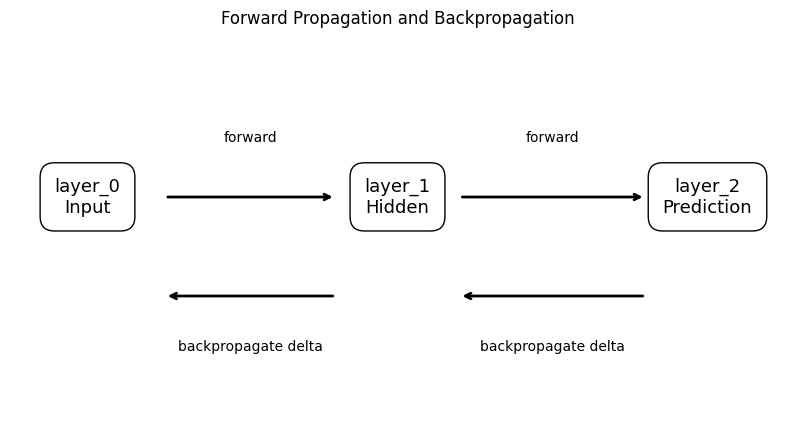

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

positions = {
    "layer_0\nInput": (0.1, 0.5),
    "layer_1\nHidden": (0.5, 0.5),
    "layer_2\nPrediction": (0.9, 0.5)
}

for text_label, (x0, y0) in positions.items():
    ax.text(x0, y0, text_label, ha="center", va="center", fontsize=13,
            bbox=dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black"))

ax.annotate("", xy=(0.42, 0.5), xytext=(0.20, 0.5),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(0.82, 0.5), xytext=(0.58, 0.5),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.annotate("", xy=(0.58, 0.32), xytext=(0.82, 0.32),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(0.20, 0.32), xytext=(0.42, 0.32),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.text(0.31, 0.60, "forward", ha="center")
ax.text(0.70, 0.60, "forward", ha="center")
ax.text(0.70, 0.22, "backpropagate delta", ha="center")
ax.text(0.31, 0.22, "backpropagate delta", ha="center")

ax.set_xlim(0, 1)
ax.set_ylim(0.1, 0.8)
ax.axis("off")
ax.set_title("Forward Propagation and Backpropagation")
plt.show()

## 14. One Iteration of Backpropagation

Buku menggunakan contoh dengan:
- `np.random.seed(1)`
- `alpha = 0.2`
- `hidden_size = 3`
- `weights_0_1` berukuran `(3, 3)`
- `weights_1_2` berukuran `(3, 1)`

Urutannya:

1. Forward propagation
2. Hitung `error`
3. Hitung `layer_2_delta`
4. Hitung `layer_1_delta`
5. Update `weights_1_2`
6. Update `weights_0_1`

In [ ]:
np.random.seed(1)

lights = np.array([
    [1, 0, 1],
    [0, 1, 1],
    [0, 0, 1],
    [1, 1, 1]
])

walk_stop = np.array([[1, 1, 0, 0]]).T

alpha = 0.2
hidden_size = 3

weights_0_1_bp = 2*np.random.random((3, hidden_size)) - 1
weights_1_2_bp = 2*np.random.random((hidden_size, 1)) - 1

def relu2deriv(output):
    return output > 0

layer_0 = lights[0:1]
layer_1 = np.dot(layer_0, weights_0_1_bp)
layer_1 = relu(layer_1)
layer_2 = np.dot(layer_1, weights_1_2_bp)

error = (layer_2 - walk_stop[0:1]) ** 2
layer_2_delta = layer_2 - walk_stop[0:1]

print("layer_0:", layer_0)
print("layer_1:", layer_1)
print("layer_2:", layer_2)
print("error:", error)
print("layer_2_delta:", layer_2_delta)

layer_0: [[1 0 1]]
layer_1: [[-0.          0.13177044 -0.        ]]
layer_2: [[-0.02129555]]
error: [[1.0430446]]
layer_2_delta: [[-1.02129555]]


In [ ]:
layer_1_delta = layer_2_delta.dot(weights_1_2_bp.T)
layer_1_delta *= relu2deriv(layer_1)

weights_1_2_before = weights_1_2_bp.copy()
weights_0_1_before = weights_0_1_bp.copy()

weights_1_2_bp -= alpha * layer_1.T.dot(layer_2_delta)
weights_0_1_bp -= alpha * layer_0.T.dot(layer_1_delta)

print("layer_1_delta:", layer_1_delta)
print("\nweights_1_2 before:")
print(weights_1_2_before)
print("\nweights_1_2 after:")
print(weights_1_2_bp)

layer_1_delta: [[-0.          0.16505257 -0.        ]]

weights_1_2 before:
[[ 0.07763347]
 [-0.16161097]
 [ 0.370439  ]]

weights_1_2 after:
[[ 0.07763347]
 [-0.13469566]
 [ 0.370439  ]]


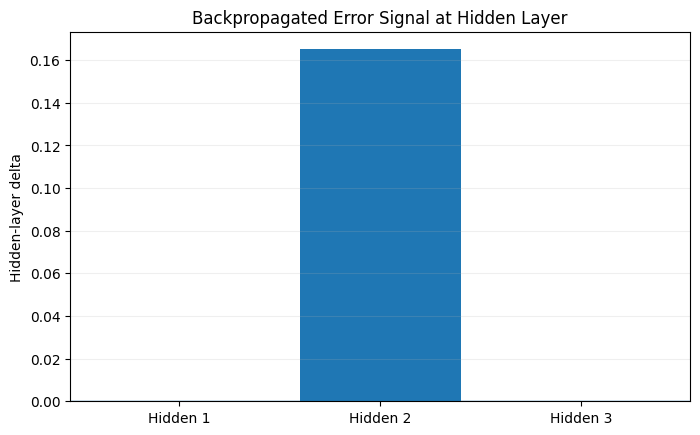

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.8))

delta_values = np.ravel(layer_1_delta)

ax.bar(["Hidden 1", "Hidden 2", "Hidden 3"], delta_values)
ax.axhline(0, linewidth=1)
ax.set_ylabel("Hidden-layer delta")
ax.set_title("Backpropagated Error Signal at Hidden Layer")
ax.grid(axis="y", alpha=0.2)

plt.show()

### Intuisi `layer_1_delta`

`layer_1_delta` menunjukkan bagaimana error dari output dialokasikan kembali ke hidden nodes.

Buku menjelaskan dua faktor:
1. `layer_2_delta` diteruskan melalui `weights_1_2`
2. hasilnya dikalikan dengan `relu2deriv(layer_1)`

Jika ReLU mematikan node (`output = 0`), node tersebut tidak dianggap berkontribusi pada error sehingga delta-nya juga dimatikan.

## 15. Full Deep Neural Network

Sekarang kita gunakan **self-sufficient program** dari bagian *Putting it all together* pada buku.

Parameter utamanya:
- `np.random.seed(1)`
- `alpha = 0.2`
- `hidden_size = 4`
- `60` iterations
- ReLU pada hidden layer
- backpropagation untuk kedua weight matrices

In [ ]:
np.random.seed(1)

def relu(x):
    return (x > 0) * x

def relu2deriv(output):
    return output > 0

streetlights = np.array([
    [1, 0, 1],
    [0, 1, 1],
    [0, 0, 1],
    [1, 1, 1]
])

walk_vs_stop = np.array([[1, 1, 0, 0]]).T

alpha = 0.2
hidden_size = 4

weights_0_1 = 2*np.random.random((3, hidden_size)) - 1
weights_1_2 = 2*np.random.random((hidden_size, 1)) - 1

deep_error_history = []

for iteration in range(60):
    layer_2_error = 0

    for i in range(len(streetlights)):
        layer_0 = streetlights[i:i+1]
        layer_1 = relu(np.dot(layer_0, weights_0_1))
        layer_2 = np.dot(layer_1, weights_1_2)

        layer_2_error += np.sum((layer_2 - walk_vs_stop[i:i+1]) ** 2)

        layer_2_delta = (layer_2 - walk_vs_stop[i:i+1])
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)

        weights_1_2 -= alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 -= alpha * layer_0.T.dot(layer_1_delta)

    deep_error_history.append(layer_2_error)

    if iteration % 10 == 9:
        print("Error:" + str(layer_2_error))

Error:0.6342311598444467
Error:0.3583840767631751
Error:0.08301831133032973
Error:0.006467054957103672
Error:0.0003292669000750735
Error:1.5055622665134864e-05


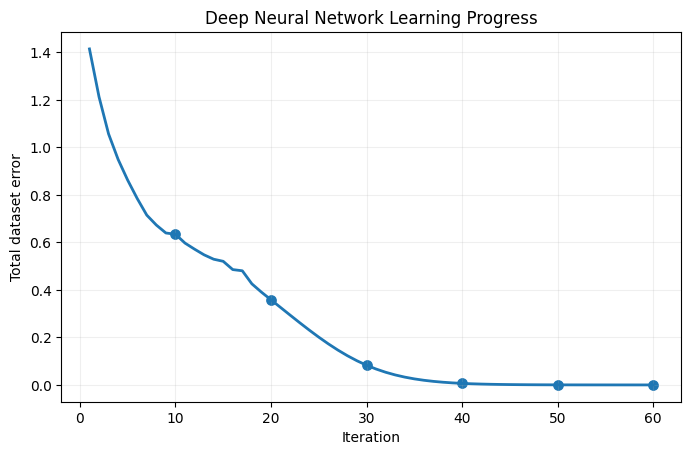

Checkpoint errors:
Iteration 10: 0.634231159844
Iteration 20: 0.358384076763
Iteration 30: 0.0830183113303
Iteration 40: 0.0064670549571
Iteration 50: 0.000329266900075
Iteration 60: 1.50556226651e-05


In [ ]:
# Angka berikut berasal dari history runtime notebook, bukan dibuat manual.
checkpoints = [9, 19, 29, 39, 49, 59]

plt.figure(figsize=(8, 4.8))
plt.plot(np.arange(1, 61), deep_error_history, linewidth=2)
plt.scatter(np.array(checkpoints) + 1,
            np.array(deep_error_history)[checkpoints],
            s=45)
plt.xlabel("Iteration")
plt.ylabel("Total dataset error")
plt.title("Deep Neural Network Learning Progress")
plt.grid(alpha=0.2)
plt.show()

print("Checkpoint errors:")
for idx in checkpoints:
    print(f"Iteration {idx+1}: {deep_error_history[idx]:.12g}")

### Membandingkan dengan output buku

Buku menampilkan checkpoint error untuk iteration 10, 20, 30, 40, 50, dan 60:

- `0.634231159844`
- `0.358384076763`
- `0.0830183113303`
- `0.0064670549571`
- `0.000329266900075`
- `1.50556226651e-05`

Notebook menghitung ulang proses yang sama sehingga chart berasal dari **runtime code**, bukan angka yang digambar secara manual.

Predictions: [1.         0.99855326 0.00263144 0.        ]
Targets: [1 1 0 0]


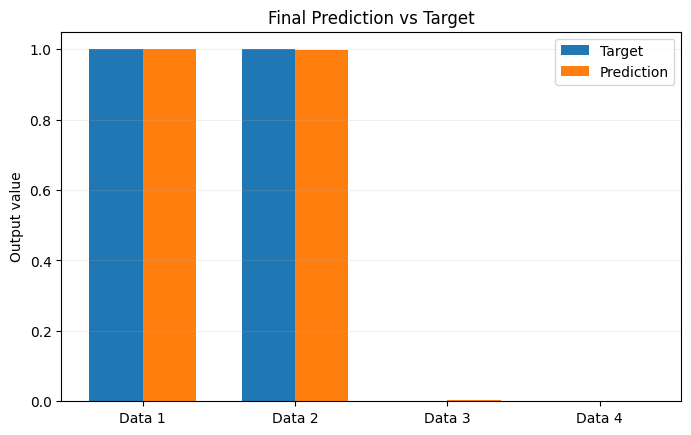

In [ ]:
# Evaluasi akhir: prediction untuk setiap training example
final_predictions = []

for i in range(len(streetlights)):
    layer_0 = streetlights[i:i+1]
    layer_1 = relu(np.dot(layer_0, weights_0_1))
    layer_2 = np.dot(layer_1, weights_1_2)
    final_predictions.append(float(layer_2[0, 0]))

final_predictions = np.array(final_predictions)
targets = walk_vs_stop.ravel()

print("Predictions:", final_predictions)
print("Targets:", targets)

plt.figure(figsize=(8, 4.8))
x = np.arange(len(targets))
width = 0.35
plt.bar(x - width/2, targets, width, label="Target")
plt.bar(x + width/2, final_predictions, width, label="Prediction")
plt.xticks(x, [f"Data {i+1}" for i in range(len(targets))])
plt.ylabel("Output value")
plt.title("Final Prediction vs Target")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()

## 16. Why Do Deep Networks Matter?

Buku menggunakan analogi bahwa pada masalah yang lebih kompleks, tidak selalu ada satu input langsung yang berkorelasi dengan output.

Hidden layer dapat membuat **intermediate representations**.

Contoh konseptual yang diberikan buku untuk image recognition:
- pixel individual mungkin tidak cukup informatif untuk mendeteksi cat;
- hidden layer dapat menangkap konfigurasi seperti bagian telinga atau mata;
- layer berikutnya menggunakan konfigurasi tersebut untuk membuat prediction yang lebih kompleks.

Inilah inti dari **deep learning**: membuat intermediate layers yang membantu menemukan correlation yang lebih kompleks.

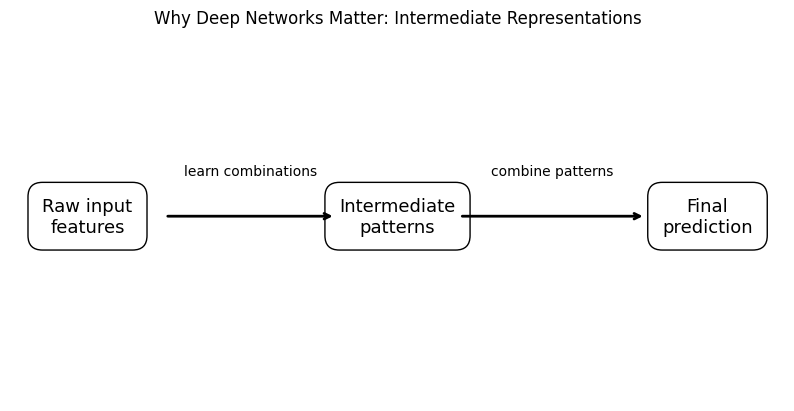

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.8))

nodes = [
    ("Raw input\nfeatures", 0.10),
    ("Intermediate\npatterns", 0.50),
    ("Final\nprediction", 0.90)
]

for label, x in nodes:
    ax.text(x, 0.5, label, ha="center", va="center", fontsize=13,
            bbox=dict(boxstyle="round,pad=0.8", facecolor="white", edgecolor="black"))

ax.annotate("", xy=(0.42, 0.5), xytext=(0.20, 0.5),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(0.82, 0.5), xytext=(0.58, 0.5),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.text(0.31, 0.61, "learn combinations", ha="center")
ax.text(0.70, 0.61, "combine patterns", ha="center")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Why Deep Networks Matter: Intermediate Representations")
plt.show()

## Concept Check

| Pertanyaan | Jawaban singkat |
|---|---|
| Apa itu `layer_0`? | Input data |
| Apa fungsi `layer_1`? | Membentuk intermediate representation |
| Apa fungsi ReLU? | Mematikan nilai negatif dan mempertahankan nilai positif |
| Apa itu `layer_2`? | Final prediction |
| Apa tujuan backpropagation? | Mengatribusikan error ke layer/weight sebelumnya |
| Mengapa ada `layer_1_delta`? | Untuk mengetahui arah/peran error pada hidden layer |
| Apa yang dipelajari network? | Correlation antara input dan output |
| Mengapa deep network berguna? | Dapat membentuk intermediate representations untuk correlation yang lebih kompleks |

## Key Takeaways

1. Data dunia nyata dapat direpresentasikan sebagai **matrix**.
2. Neural network dapat mempelajari satu dataset penuh melalui repeated prediction dan weight update.
3. **Stochastic gradient descent** melakukan update setelah setiap training example.
4. Weight yang besar dapat menunjukkan input yang memiliki correlation kuat terhadap output.
5. Tidak semua correlation bersifat langsung; hidden layer membantu membentuk **intermediate data**.
6. **ReLU** memberikan nonlinearity dan memungkinkan *sometimes/conditional correlation*.
7. **Backpropagation** menghitung bagaimana error output harus diteruskan ke layer sebelumnya.
8. Deep neural network menggabungkan forward propagation, error calculation, backpropagation, dan weight update.

## Chapter Summary

Chapter 6 membawa konsep Chapter 3–5 menjadi sebuah **deep neural network** sederhana.

Alur lengkapnya:

**Input → Weighted Sum → ReLU → Hidden Representation → Weighted Sum → Prediction → Error → Backpropagation → Weight Update**

Hal terpenting yang perlu dibawa ke chapter berikutnya adalah bahwa hidden layer bukan sekadar layer tambahan. Hidden layer memungkinkan network membentuk **representasi antara** yang dapat menangkap correlation yang tidak tersedia secara langsung pada input-output.

Chapter berikutnya membahas cara **membaca dan menggambar neural network** dengan lebih sederhana.

## Reference

Trask, A. W. *Grokking Deep Learning*. Manning Publications.

**Source basis:** Chapter 6, *Building Your First Deep Neural Network: Introduction to Backpropagation*, terutama bagian *The Streetlight Problem*, *Preparing the Data*, *Matrices and the Matrix Relationship*, *Building a Neural Network*, *Full, Batch, and Stochastic Gradient Descent*, *Neural Networks Learn Correlation*, *Overfitting*, *Conflicting Pressure*, *Learning Indirect Correlation*, *The Secret to Sometimes Correlation*, *Backpropagation*, *Backpropagation in Code*, dan *Putting It All Together*.